In [72]:
!pip install numpy scipy scikit-learn pot

In [73]:
!git clone https://github.com/mint-vu/PGW_Metric.git


fatal: destination path 'PGW_Metric' already exists and is not an empty directory.


In [74]:
import sys
import os

# プロジェクトのルートディレクトリ名
repo_name_1 = '/content/PGW_Metric'

# システムパスに追加
if repo_name_1 not in sys.path:
    # 現在の作業ディレクトリにプロジェクトフォルダが存在する場合のパスを設定
    sys.path.append(os.path.abspath(repo_name_1))

print(f"'{repo_name_1}' をシステムパスに追加しました。")
# リポジトリ内の src フォルダから pgw_metric モジュールをインポート
# （リポジトリの構造に応じて 'src.pgw_metric' のように指定します）
# lib パッケージ内の gromov モジュールを gromov という名前でインポート
from lib import gromov

# これで gromov.gromov_wasserstein(...) のようにアクセス可能です

'/content/PGW_Metric' をシステムパスに追加しました。


In [75]:
import numpy as np
s = 42
np.random.seed(s)

In [76]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg as spl
import scipy.spatial as sps
import ot
from scipy.stats import multivariate_normal
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import plotly.graph_objects as go
import sklearn.mixture as sklmi
import sklearn.manifold as sklma
from tqdm import tqdm
import warnings
import os, sys
import itertools
import scipy as sp
from sklearn.datasets import make_blobs
from scipy.stats import special_ortho_group
from sklearn.neighbors import NearestNeighbors



### utils ###

class Gaussian:
    ### class encoding a Gaussian distribution ###

    def __init__(self,mean,cov):
        self.mean = np.array(mean)
        self.cov = np.array(cov)
        self.dim = len(mean)

    def sample(self,n_samples):
        return np.random.multivariate_normal(self.mean,self.cov,n_samples)

    def pdf(self,x):
        return multivariate_normal.pdf(x,mean=self.mean,cov=self.cov)



class GaussianMixture:
    ### Gaussian mixture distribution ###

    def __init__(self,weights_list,mean_list,cov_list):
        self.comp = [Gaussian(mean_list[k],cov_list[k]) for k in range(len(mean_list))]
        self.comp_mean = np.array(mean_list)
        self.comp_cov = np.array(cov_list)
        self.weights = np.array(weights_list)
        self.dim = len(mean_list[0])
        self.K = len(mean_list)


    def sample(self,n_samples,return_K=False):
        """
        if return_K, return the list of component indice for each sample
        """
        idx_list = np.random.choice(np.arange(self.K),n_samples,p=self.weights)
        samples_list = [np.random.multivariate_normal(self.comp_mean[i],self.comp_cov[i]) for i in idx_list]
        if return_K:
            return np.array(samples_list), idx_list
        else:
            return np.array(samples_list)

    def mean(self):
        ### return the mean of the Gaussian mixture
        return np.average(self.comp_mean,axis=0,weights=self.weights)

    def cov(self):
        ### return the covariance matrix of the Gaussian mixture
        A = sum([self.weights[k]*(self.comp_cov[k]+np.outer(self.comp_mean[k],self.comp_mean[k])) for k in range(self.K)])
        mean = self.mean()
        return A - np.outer(mean,mean)


    def pdf(self,x):
        return sum([self.weights[k]*multivariate_normal.pdf(x,mean=self.comp_mean[k],cov=self.comp_cov[k]) for k in range(self.K)])


    def plot_scatter_2d(self,n_samples,T=None,*args):
        ### utils for Figures 3 and 4
        X, idx_list = self.sample(n_samples,True)
        grad_color = np.array([(x/np.max(X[:,0]),y/np.max(X[:,1]),x/np.max(X[:,0]),1) for x,y in X])
        if T is not None:
            Y = np.array([T(X[k],idx_list[k],*args) for k in range(len(X))])
        else:
            Y = X
        cmap_list = ['spring', 'summer', 'autumn', 'winter', 'cool',
                      'Wistia', 'hot', 'afmhot', 'gist_heat', 'copper','viridis', 'plasma', 'inferno', 'magma', 'cividis']
        for k in range(self.K):
            Z = Y[idx_list==k]
            plt.scatter(Z[:,0],Z[:,1],color=X[idx_list==k][:,0],s=10)
        plt.axis('equal')



    def pdist(self,f):
        ### compute pairwise distances matrix
        dist_list = [[f(self.comp_mean[k],self.comp_mean[l],self.comp_cov[k],self.comp_cov[l]) for l in range(k+1,self.K)] for k in range(self.K)][:-1]
        dist_matrix = np.zeros((self.K,self.K))
        for k in range(self.K):
            for l in range(k+1,self.K):
                dist_matrix[k,l] = dist_list[k][l-k-1]
                dist_matrix[l,k] = dist_matrix[k,l]
        return dist_matrix






def gmm_transform(mu,P=None,b=None):
    ### Apply a linear transformation x -> Px + b to the Gaussian mixture
    if P is None:
        P = np.eye(mu.dim)
    if b is None:
        b = np.zeros(P.shape[0])
    mean_list = [P.dot(m) + b for m in mu.comp_mean]
    cov_list = [P@A@P.T for A in mu.comp_cov]
    return GaussianMixture(mu.weights,mean_list,cov_list)


def I(m,n):
    ### rectangular matrix (I_n  0)^T
    I = np.zeros((m,n))
    I[:n,:n] = np.eye(n)
    return I


def proj_stiefel(A):
    ### projection on Stiefel Manifold
    m,n = A.shape
    U, s, VT = spl.svd(A)
    return U @ I(m,n) @ VT


def gaussian_w2_squared(mean_0,mean_1,Cov_0,Cov_1):
    ### squared W_2 distance between Gaussian distributions (this returns W_2^2, not W_2)
    sqCov_1 = spl.sqrtm(Cov_1).real
    return spl.norm(mean_0 - mean_1)**2 + np.trace(Cov_0) + np.trace(Cov_1) - 2*np.trace(spl.sqrtm(sqCov_1@Cov_0@sqCov_1).real)

# backward-compatible alias: the rest of the notebook (mu.pdist(GaussianW2), gaussian_cost_matrix,
# gaussian_W, grad, proj_gradient_descent, MGW2_GM, ...) still refers to this name.
GaussianW2 = gaussian_w2_squared

def gaussian_cost_matrix(gmm):
    K = gmm.K
    C = np.zeros((K,K))
    for i in range(K):
        for j in range(K):
            C[i,j] = GaussianW2(gmm.comp_mean[i], gmm.comp_mean[j],
                                gmm.comp_cov[i],  gmm.comp_cov[j])
    return C

def gaussian_W(gmm1, gmm2):
    K = gmm1.K
    L = gmm2.K
    C = np.zeros((K,L))
    for i in range(K):
        for j in range(L):
            C[i,j] = GaussianW2(gmm1.comp_mean[i], gmm2.comp_mean[j],
                                gmm1.comp_cov[i], gmm2.comp_cov[j])
    return C




def grad_gauss(P,Cov_0,Cov_1):
    ### grad of P -> tr(Cov_1^{\frac{1}{2}}P^TCov_0PCov_1^{\frac{1}{2})
    sqCov_1 = spl.sqrtm(Cov_1).real
    A = Cov_0@P@sqCov_1
    B = spl.inv(spl.sqrtm(sqCov_1@P.T@A)).real
    return A @ B @ sqCov_1



def grad(P,weights,mu,nu):
    ### grad of P -> \sum_{k,l} weights[k,l]W_2^2(\mu_k,P_{\#}\nu_l)
    return 2*sum([weights[k,l]*(-np.outer(mu.comp_mean[k],nu.comp_mean[l])
                + P@np.outer(nu.comp_mean[l],nu.comp_mean[l])
                - grad_gauss(P,mu.comp_cov[k],nu.comp_cov[l])) for k in range(mu.K) for l in range(nu.K)])




def proj_gradient_descent(P,weights,mu,nu,alpha,n_iter=150):
    ### projected gradient descent on the Stiefel manifold
    loss = [sum([weights[k,l]*GaussianW2(0,0,mu.comp_cov[k],P@nu.comp_cov[l]@P.T) for k in range(mu.K) for l in range(nu.K)])]
    for k in range(n_iter):
        P = proj_stiefel(P-alpha*grad(P,weights,mu,nu))
        loss.append(sum([weights[k,l]*GaussianW2(0,0,mu.comp_cov[k],P@nu.comp_cov[l]@P.T) for k in range(mu.K) for l in range(nu.K)]))
    return P, loss



def T_map_Gaussian(x,mu,nu):
    ### Transport map between two Gaussian distributions mu and nu
    invcov0 = spl.inv(spl.sqrtm(mu.cov).real)
    sqcov0 = spl.sqrtm(mu.cov).real
    A = invcov0@spl.sqrtm(sqcov0@nu.cov@sqcov0)@invcov0
    if len(x.shape)==1:
        return nu.mean + A@(x - mu.mean)
    else:
        return nu.mean + np.einsum('ij,bj -> bi',A,x - mu.mean)


def T_map_Gaussian_rand(x,mu,nu,idx_list):
    ### Transport map between two Gaussian distributions mu and nu (utils for T_rand)
    invcov0 = [spl.inv(spl.sqrtm(mu.comp[k].cov).real) for k in range(mu.K)]
    sqcov0 = [spl.sqrtm(mu.comp[k].cov).real for k in range(mu.K)]
    A_list = [[invcov0[k]@spl.sqrtm(sqcov0[k]@nu.comp[l].cov@sqcov0[k])@invcov0[k] for l in range(nu.K)] for k in range(mu.K)]
    return np.array([nu.comp[idx[1]].mean + A_list[idx[0]][idx[1]]@(x[i] - mu.comp[idx[0]].mean) for i, idx in enumerate(idx_list)])



def T_mean(X,mu,nu,P,weights):
    mu_P_centered = gmm_transform(mu,P=P.T,b=-P.T@mu.mean())
    nu_centered = gmm_transform(nu,b=-nu.mean())
    pdf_comp = [mu.comp[k].pdf(X) for k in range(mu.K)]
    ipdf_mu = 1./mu.pdf(X)
    if len(X.shape)==1:
        X_P = P.T@(X - mu.mean())
        Y = sum([weights[k,l]*pdf_comp[k]*T_map_Gaussian(X_P,mu_P_centered.comp[k],nu_centered.comp[l]) for k in range(mu.K) for l in range(nu.K)])*ipdf_mu
    else:
        X_P = np.einsum('ij,bj->bi',P.T,X - mu.mean())
        Y = np.einsum('bi,b -> bi',sum([weights[k,l]*np.einsum('bi,b -> bi',T_map_Gaussian(X_P,mu_P_centered.comp[k],nu_centered.comp[l]),pdf_comp[k]) for k in range(mu.K) for l in range(nu.K)]),ipdf_mu)
    return Y + nu.mean()


def T_rand(x,mu,nu,P,weights):
    mu_P_centered = gmm_transform(mu,P=P.T,b=-P.T@mu.mean())
    nu_centered = gmm_transform(nu,b=-nu.mean())
    rng = np.random.default_rng()
    probs = np.array([weights[k,l]*mu.comp[k].pdf(x)/mu.pdf(x) for k in range(mu.K) for l in range(nu.K)])
    idx_list = [rng.choice([[k,l] for k in range(mu.K) for l in range(nu.K)],p=prob) for prob in probs.T]
    return T_map_Gaussian_rand(x,mu_P_centered,nu_centered,idx_list)




## Main algo



def MGW2_GM(mu,nu):
    ### core method between two Gaussian mixtures (returns a distance)
    dist_matrix_mu = mu.pdist(GaussianW2)
    dist_matrix_nu = nu.pdist(GaussianW2)
    M1  = np.max(dist_matrix_mu)
    M2  = np.max(dist_matrix_nu)
    M = max(M1,M2)
    dist_matrix_mu = dist_matrix_mu/M1
    dist_matrix_nu = dist_matrix_nu/M2
    return ot.gromov.gromov_wasserstein2(dist_matrix_mu,dist_matrix_nu,mu.weights,nu.weights,loss_fun='square_loss')



def aMGW2_GM(mu,nu,n_step=10,reg_init=1,beta=0.95,verbose=False):
    ### core method with annealed scheme
    reg = reg_init
    weights = np.outer(mu.weights,nu.weights)
    for k in range(n_step):
        weights = ot.gromov.entropic_gromov_wasserstein(mu.pdist(GaussianW2),nu.pdist(GaussianW2),mu.weights,nu.weights,loss_fun='square_loss',epsilon=reg,G0=weights)
        reg *= beta
    return ot.gromov.gromov_wasserstein2(mu.pdist(GaussianW2),nu.pdist(GaussianW2),mu.weights,nu.weights,loss_fun='square_loss',G0=weights)




def MGW2(X,Y,n_components=20,annealing=False):
    ### MGW2 between two clouds of points (returns a distance)
    mix = sklmi.GaussianMixture(n_components=n_components)
    mix.fit(X)
    mu = GaussianMixture(mix.weights_,mix.means_,mix.covariances_)
    del mix
    mix = sklmi.GaussianMixture(n_components=n_components)
    mix.fit(Y)
    nu = GaussianMixture(mix.weights_,mix.means_,mix.covariances_)
    del mix
    if annealing:
        return aMGW2_GM(mu,nu)
    else:
        return MGW2_GM(mu,nu)



def MGW2_GM_coup(mu,nu):
    ### core method between two Gaussian Mixtures (return a coupling between Gaussian components)
    return ot.gromov.gromov_wasserstein(mu.pdist(GaussianW2),nu.pdist(GaussianW2),mu.weights,nu.weights,loss_fun='square_loss')



def aMGW2_GM_coup(mu,nu,n_step=10,reg_init=1,beta=0.95,verbose=False):
    ### core method with annealed scheme
    reg = reg_init
    weights = np.outer(mu.weights,nu.weights)
    for k in range(n_step):
        weights = ot.gromov.entropic_gromov_wasserstein(mu.pdist(GaussianW2),nu.pdist(GaussianW2),mu.weights,nu.weights,loss_fun='square_loss',epsilon=reg,G0=weights)
        reg *= beta
    return ot.gromov.gromov_wasserstein(mu.pdist(GaussianW2),nu.pdist(GaussianW2),mu.weights,nu.weights,loss_fun='square_loss',G0=weights)



def MGW2_coup(X,Y,n_components=20,annealing=False,method='T_rand',points=True,return_both=False,verbose=False):
    """
    MGW2 between two clouds of points (return a map between the points)
    If points = False, return the direct output of the T_mean or T_rand map (not in Y),
    if points = True, return the idxs of the points in Y where the points in X are transported at.
    """
    if verbose:
        print('fitting mixture 1')
    mix = sklmi.GaussianMixture(n_components=n_components)
    mix.fit(X)
    mu = GaussianMixture(mix.weights_,mix.means_,mix.covariances_)
    del mix
    if verbose:
        print('fitting mixture 2')
    mix = sklmi.GaussianMixture(n_components=n_components)
    mix.fit(Y)
    nu = GaussianMixture(mix.weights_,mix.means_,mix.covariances_)
    del mix
    if verbose:
        print('deriving coupling between GMMs')
    if annealing:
        weights = aMGW2_GM_coup(mu,nu)
    else:
        weights = MGW2_GM_coup(mu,nu)
    if verbose:
        print('deriving map from coupling')
    P = proj_stiefel(sum([weights[k,l]*np.outer(mu.comp_mean[k],nu.comp_mean[l]) for k in range(mu.K) for l in range(nu.K)]))
    P, loss  = proj_gradient_descent(P,weights,mu,nu,1)
    if method=='T_mean':
        Z = T_mean(X,mu,nu,P,weights)
    elif method=='T_rand':
        Z = T_rand(X,mu,nu,P,weights)
    if return_both:
        nbrs = NearestNeighbors(n_neighbors=1, algorithm='ball_tree').fit(Y)
        idx = nbrs.kneighbors(Z,return_distance=False).ravel()
        return idx, Z
    elif points:
        nbrs = NearestNeighbors(n_neighbors=1, algorithm='ball_tree').fit(Y)
        idx = nbrs.kneighbors(Z,return_distance=False).ravel()
        return idx
    else:
        return Z


### MEW2 ###


def MEW2_GM(mu,nu,alpha,n_iter_P=150,eps=1e-3,n_iter_max=1000,init='Gaussian',initw=None,init_phase=True,symmetry=True,verbose=False):

    ### core method between two Gaussian mixtures mu and nu

    def twistedGaussianW2(mean_0,mean_1,Cov_0,Cov_0_full,Cov_1):
        sqCov_1 = spl.sqrtm(Cov_1).real
        return spl.norm(mean_0 - mean_1)**2 + np.trace(Cov_0_full) + np.trace(Cov_1) - 2*np.trace(spl.sqrtm(sqCov_1@Cov_0@sqCov_1).real)


    def compute_weights_loss(P,mu,nu,loss_only=False,w=None):
        mu_P = gmm_transform(mu,P=P.T)
        M = np.array([[twistedGaussianW2(mu_P.comp_mean[k],nu.comp_mean[l],mu_P.comp_cov[k],mu.comp_cov[k],nu.comp_cov[l]) for l in range(nu.K)] for k in range(mu.K)])
        del mu_P
        if not loss_only:
            weights = ot.emd(mu.weights,nu.weights,M)
        else:
            weights = w
        loss = np.sum(weights*M)
        if loss_only:
            return loss
        else:
            return weights, loss


    def initialize(P,mu,nu,symmetry=False):
        P_list = P@[np.diag(a) for a in itertools.product([1,-1],repeat=P.shape[1])]
        weights_list, loss_list = [], []
        for k in range(len(P_list)):
            weights, loss = compute_weights_loss(P_list[k],mu,nu)
            weights_list.append(weights)
            loss_list.append(loss)
        idx = np.argmin(loss_list)
        P = P_list[idx]
        weights = weights_list[idx]
        loss = loss_list[idx]
        if symmetry:
            P_list = [P[:,a] for a in itertools.permutations(range(P.shape[1]))]
            weights_list, loss_list = [], []
            for k in range(len(P_list)):
                weights, loss = compute_weights_loss(P_list[k],mu,nu)
                weights_list.append(weights)
                loss_list.append(loss)
            idx = np.argmin(loss_list)
            P = P_list[idx]
            weights = weights_list[idx]
            loss = loss_list[idx]

        return P, weights, loss


    if type(init) == str:
        s0, P0 = spl.eigh(mu.cov())
        s1, P1 = spl.eigh(nu.cov())
        P0 = P0[:,::-1]
        P1 = P1[:,::-1]


    mu = gmm_transform(mu,b=-mu.mean())
    nu = gmm_transform(nu,b=-nu.mean())





    if type(init) == str:
        if init=='Gaussian':
            P = P0@I(mu.dim,nu.dim)@P1.T
        elif init=='random':
            P = proj_stiefel(np.random.rand(mu.dim,nu.dim))
    else:
        P = init
    if initw is None:
        if init_phase:
            P, weights, loss = initialize(P,mu,nu,symmetry)
        else:
            weights, loss = compute_weights_loss(P,mu,nu)
    else:
        weights = initw
        loss = compute_weights_loss(P,mu,nu,True,weights)
    loss_old = 0
    #print('initialization, loss = ' + str(loss))
    n_iter = 0
    while n_iter < n_iter_max and np.abs(loss - loss_old) > eps:
        if verbose:
            print('iteration ' + str(n_iter) + ': loss = ' + str(loss))
        loss_old = loss
        P, _ = proj_gradient_descent(P,weights,mu,nu,alpha,n_iter = n_iter_P)
        weights, loss = compute_weights_loss(P,mu,nu)
        #print('iteration: ' + str(k+1) + ', loss = ' + str(loss))
        n_iter += 1

    return  P, weights, loss



def EW2(X,Y,a=None,b=None,eps=1e-3,n_iter_max=10000,verbose=False):
    ### EW2 between two clouds of points (https://arxiv.org/pdf/1806.09277.pdf)
    m = X.shape[1]
    n = Y.shape[1]
    if a is None:
        a = ot.unif(X.shape[0])
    if b is None:
        b = ot.unif(Y.shape[0])
    P = proj_stiefel(np.random.rand(m,n))
    M = ot.dist(X,np.einsum('mn,bn->bm',P,Y))
    weights = ot.emd(a,b,M,numItermax=1000000)
    loss = np.trace(weights.T@M)
    loss_old = 0
    n_iter = 0
    while n_iter < n_iter_max and np.abs(loss-loss_old) > eps:
        if verbose:
            print('iteration ' + str(n_iter) + ': loss = ' + str(loss))
        loss_old = loss
        P = proj_stiefel(X.T@weights@Y)
        M = ot.dist(X,np.einsum('mn,bn->bm',P,Y))
        weights = ot.emd(a,b,M,numItermax=1000000)
        loss = np.trace(weights.T@M)
        n_iter += 1
    return P, weights, loss


def aEW2(X,Y,a=None,b=None,eps=1e-3,n_iter_max=10000,reg_init=1,beta=0.95,verbose=False):
    ### EW2 with annealed scheme (https://arxiv.org/pdf/1806.09277.pdf)
    m = X.shape[1]
    n = Y.shape[1]
    P = proj_stiefel(np.random.rand(m,n))
    M = ot.dist(X,np.einsum('mn,bn->bm',P,Y))
    if a is None:
        a = ot.unif(X.shape[0])
    if b is None:
        b = ot.unif(Y.shape[0])
    reg = reg_init
    weights = ot.bregman.sinkhorn_stabilized(a,b,M,reg)
    loss = np.trace(weights.T@M)
    loss_old = 0
    n_iter = 0
    while n_iter < n_iter_max and np.abs(loss-loss_old) > eps:
        if verbose:
            print('iteration ' + str(n_iter) + ': loss = ' + str(loss))
        loss_old = loss
        reg *= beta
        P = proj_stiefel(X.T@weights@Y)
        M = ot.dist(X,np.einsum('mn,bn->bm',P,Y))
        a = ot.unif(X.shape[0])
        b = ot.unif(Y.shape[0])
        weights = ot.bregman.sinkhorn_stabilized(a,b,M,reg)
        loss = np.trace(weights.T@M)
        n_iter += 1
    return P, weights, loss


def MEW2(X,Y,n_components=20,annealing=True,n_iter_annealing=10,beta=0.99):
    ### MEW2 between two clouds of points (returns a distance)
    mix = sklmi.GaussianMixture(n_components=n_components)
    mix.fit(X)
    mu = GaussianMixture(mix.weights_,mix.means_,mix.covariances_)
    del mix
    mix = sklmi.GaussianMixture(n_components=n_components)
    mix.fit(Y)
    nu = GaussianMixture(mix.weights_,mix.means_,mix.covariances_)
    del mix
    if annealing:
        P, weights, loss =  aEW2(mu.comp_mean,nu.comp_mean,n_iter_max=n_iter_annealing,beta=0.99,verbose=False)
        P, weights, loss = MEW2_GM(mu,nu,alpha=0.01,eps=1e-3,n_iter_P=150,init=P,init_phase=False,symmetry=False,verbose=False)
    else:
        P, weights, loss = MEW2_GM(mu,nu,alpha=0.01,eps=1e-3,n_iter_P=150,init_phase=True,symmetry=True,verbose=False)
    return loss


def MEW2_coup(X,Y,n_components=20,annealing=True,n_iter_annealing=10,beta=0.99,method='T_rand',points=True,return_both=False):
    """
    MEW2 between two clouds of points (return a map between the points)
    If points = False, return the direct output of the T_mean or T_rand map (not in Y),
    if points = True, return the idxs of the points in Y where the points in X are transported at.
    """
    mix = sklmi.GaussianMixture(n_components=n_components)
    mix.fit(X)
    mu = GaussianMixture(mix.weights_,mix.means_,mix.covariances_)
    del mix
    mix = sklmi.GaussianMixture(n_components=n_components)
    mix.fit(Y)
    nu = GaussianMixture(mix.weights_,mix.means_,mix.covariances_)
    del mix
    if annealing:
        P, weights, loss =  aEW2(mu.comp_mean,nu.comp_mean,n_iter_max=n_iter_annealing,beta=0.99,verbose=False)
        P, weights, loss = MEW2_GM(mu,nu,alpha=0.01,eps=1e-3,n_iter_P=150,init=P,init_phase=False,symmetry=False,verbose=False)
    else:
        P, weights, loss = MEW2_GM(mu,nu,alpha=0.01,eps=1e-3,n_iter_P=150,init_phase=True,symmetry=True,verbose=False)
    if method=='T_mean':
        Z = T_mean(X,mu,nu,P,weights)
    elif method=='T_rand':
        Z = T_rand(X,mu,nu,P,weights)
    if return_both:
        nbrs = NearestNeighbors(n_neighbors=1, algorithm='ball_tree').fit(Y)
        idx = nbrs.kneighbors(Z,return_distance=False).ravel()
        return idx, Z
    elif points:
        nbrs = NearestNeighbors(n_neighbors=1, algorithm='ball_tree').fit(Y)
        idx = nbrs.kneighbors(Z,return_distance=False).ravel()
        return idx
    else:
        return Z

In [77]:
### Partial MGW: matched statistics, alignment, barycentric map ###
#
# These helpers implement the corrections in Sections 4.2-4.5 of the
# correction guide:
#   - Gamma (the raw partial-GW coupling) is never perturbed (no "+ eps").
#   - centering/alignment use matched statistics (row/col sums of Gamma),
#     not the full-mixture means mu.mean()/nu.mean().
#   - the alignment loss and its gradient are evaluated on the SAME
#     centered, matched objective J_Gamma(P).
#   - the barycentric map is normalized by the matched source density,
#     not by the full source density mu.pdf(X).

def validate_partial_coupling(gamma, a, b, tol=1e-8):
    ### check that gamma is a feasible (non-negative, sub-marginal) partial coupling
    gamma = np.asarray(gamma, dtype=float)
    if np.any(gamma < -tol):
        raise ValueError("Partial coupling Gamma has negative entries.")
    if np.any(gamma.sum(axis=1) > np.asarray(a) + tol):
        raise ValueError("Partial coupling violates the source marginal a (Gamma 1 <= a).")
    if np.any(gamma.sum(axis=0) > np.asarray(b) + tol):
        raise ValueError("Partial coupling violates the target marginal b (Gamma^T 1 <= b).")
    Z = float(gamma.sum())
    if not (0.0 < Z <= 1.0 + tol):
        raise ValueError(f"Z_lambda = {Z} is out of the expected (0, 1] range.")
    return Z


def matched_statistics(gamma, mu, nu, mass_tol=1e-14):
    ### Z_lambda, row/col matched masses, and matched means m0_lambda, m1_lambda
    gamma = np.asarray(gamma, dtype=float)
    Z = float(gamma.sum())
    if not np.isfinite(Z) or Z <= mass_tol:
        raise ValueError("The partial coupling has zero matched mass (Z_lambda <= 0); "
                          "barycentric map is undefined.")
    row_mass = gamma.sum(axis=1)   # r_k = sum_l Gamma[k,l]
    col_mass = gamma.sum(axis=0)   # s_l = sum_k Gamma[k,l]
    m0 = (row_mass[:, None] * mu.comp_mean).sum(axis=0) / Z
    m1 = (col_mass[:, None] * nu.comp_mean).sum(axis=0) / Z
    return Z, row_mass, col_mass, m0, m1


def alignment_loss(P, gamma, mu_c, nu_c):
    ### J_Gamma(P) = sum_{k,l} Gamma[k,l] * W2^2(centered_mu_k, P_# centered_nu_l)
    ### mu_c, nu_c must already be centered on the MATCHED means m0_lambda, m1_lambda
    value = 0.0
    for k in range(mu_c.K):
        for l in range(nu_c.K):
            if gamma[k, l] == 0.0:
                continue
            target_mean = P @ nu_c.comp_mean[l]
            target_cov = P @ nu_c.comp_cov[l] @ P.T
            value += gamma[k, l] * gaussian_w2_squared(
                mu_c.comp_mean[k], target_mean, mu_c.comp_cov[k], target_cov
            )
    return float(value)


def alignment_grad(P, gamma, mu_c, nu_c):
    ### gradient of J_Gamma(P); reuses the existing grad_gauss/grad formulas,
    ### but on matched-centered GMMs so it matches alignment_loss exactly.
    return grad(P, gamma, mu_c, nu_c)


def partial_projected_gradient_descent(P0, gamma, mu_c, nu_c, step_size=1.0, max_iter=150, tol=1e-8):
    ### projected gradient descent on the Stiefel manifold for J_Gamma(P);
    ### the recorded loss and the update direction are the same functional.
    P = P0.copy()
    losses = [alignment_loss(P, gamma, mu_c, nu_c)]
    for _ in range(max_iter):
        G = alignment_grad(P, gamma, mu_c, nu_c)
        P_next = proj_stiefel(P - step_size * G)
        losses.append(alignment_loss(P_next, gamma, mu_c, nu_c))
        if np.linalg.norm(P_next - P) <= tol * (1.0 + np.linalg.norm(P)):
            P = P_next
            break
        P = P_next
    return P, losses


def partial_mgw_barycentric_map(X, mu, nu, P, gamma, m0_match, m1_match, density_tol=None):
    """
    Partial barycentric map T_b^{GW,lambda}(x), normalized by the MATCHED
    source density (not the full mixture density mu.pdf(x)):

        T_b^{GW,lambda}(x) =
            [ sum_{k,l} Gamma[k,l] p_mu_k(x) R_kl(x) ]
          / [ sum_{k,l} Gamma[k,l] p_mu_k(x) ]
          = [ sum_k  r_k p_mu_k(x)  R_k(x) ] / [ sum_k r_k p_mu_k(x) ]

    where R_kl is built from the optimal Gaussian map between the
    matched-centered mu_k and the P-embedded, matched-centered nu_l.
    Raises FloatingPointError if the matched source density underflows to
    zero, instead of silently perturbing gamma.
    """
    X = np.asarray(X, dtype=float)
    single = X.ndim == 1
    X2 = X[None, :] if single else X

    mu_P_centered = gmm_transform(mu, P=P.T, b=-P.T @ m0_match)
    nu_centered = gmm_transform(nu, b=-m1_match)

    component_pdf = np.vstack([mu.comp[k].pdf(X2) for k in range(mu.K)])  # (K, n)
    row_mass = gamma.sum(axis=1)  # r_k
    denominator = (row_mass[:, None] * component_pdf).sum(axis=0)

    if density_tol is None:
        density_tol = np.finfo(float).tiny
    if np.any(denominator <= density_tol):
        raise FloatingPointError(
            "Matched source density underflowed to zero at one or more query points; "
            "the barycentric map is not defined there."
        )

    X_P = np.einsum('ij,bj->bi', P.T, X2 - m0_match)

    numerator = np.zeros((X2.shape[0], nu.dim), dtype=float)
    for k in range(mu.K):
        for l in range(nu.K):
            if gamma[k, l] == 0.0:
                continue
            R = T_map_Gaussian(X_P, mu_P_centered.comp[k], nu_centered.comp[l])
            numerator += gamma[k, l] * component_pdf[k][:, None] * R

    mapped = numerator / denominator[:, None] + m1_match
    return mapped[0] if single else mapped


In [78]:
import time

def pMGW2_coup(
    X, Y, Lambda, n_components_X, n_components_Y,
    solver_tol=1e-12, step_size=1.0, max_alignment_iter=150,
    normalize_costs=True, points=True, return_both=False, verbose=False,
):
    """
    Partial mixture Gromov-Wasserstein coupling and (partial) barycentric map.

    Corrections applied vs. the original version (see correction guide):
      - Gamma (output of partial_gromov_ver1) is used as-is everywhere:
        no "Gamma + eps" perturbation, and the SAME Gamma is used for the
        alignment step and for the barycentric map.
      - centering uses matched statistics (Gamma's row/column masses),
        not the full-mixture means mu.mean()/nu.mean().
      - the alignment loss and its gradient are the same functional J_Gamma(P).
      - the barycentric map is normalized by the matched source density.
      - `annealing` / `n_iter_annealing` are removed (unused on this path);
        `reg` is renamed `solver_tol` since it is the solver's stopping
        tolerance, not an entropic regularization parameter.
      - T_rand is not used on the partial path: for a partial coupling its
        per-point assignment probabilities do not sum to 1 (see guide 4.6).

    Lambda is interpreted on the NORMALIZED cost scale (i.e. after C1, C2
    are divided by M = max(C1.max(), C2.max())), when normalize_costs=True.
    If you have a Lambda tuned for the raw (non-normalized) cost scale,
    convert it first: Lambda_normalized = Lambda_raw / M**2.
    """
    # 1. Fit GMMs
    mix = sklmi.GaussianMixture(n_components=n_components_X)
    mix.fit(X)
    mu = GaussianMixture(mix.weights_, mix.means_, mix.covariances_)
    del mix
    mix = sklmi.GaussianMixture(n_components=n_components_Y)
    mix.fit(Y)
    nu = GaussianMixture(mix.weights_, mix.means_, mix.covariances_)
    del mix

    # 2. Intra-mixture W2^2 cost matrices, with a zero-guard on normalization
    C1 = gaussian_cost_matrix(mu)
    C2 = gaussian_cost_matrix(nu)
    M = max(float(C1.max()), float(C2.max()))
    if normalize_costs and M > 0.0:
        C1_solver, C2_solver = C1 / M, C2 / M
    else:
        C1_solver, C2_solver = C1.copy(), C2.copy()

    a = mu.weights
    b = nu.weights

    if verbose:
        print(f'Deriving partial MGW coupling with Lambda={Lambda}')

    # 3. Solve the non-entropic partial GW coupling (p=q=2, square loss).
    start_time = time.time()
    Gamma = gromov.partial_gromov_ver1(
        C1_solver, C2_solver, a, b,
        Lambda=Lambda,
        nb_dummies=1,
        G0=None,
        thres=1,
        numItermax=None,
        numItermax_gw=1000,
        tol=solver_tol,
        log=False,
        verbose=verbose,
        line_search=True,
    )
    if np.isnan(Gamma).any():
        raise FloatingPointError("Partial GW solver returned NaN entries in Gamma.")

    # feasibility check: Gamma is used as-is from here on, never perturbed
    Z = validate_partial_coupling(Gamma, a, b)
    if verbose:
        print(f"Calculation time: {time.time() - start_time:.6f} sec")
        print(f"Total matched mass Z_lambda = {Z:.6f}")

    # 4. Matched centering (replaces full-mixture means mu.mean()/nu.mean())
    Z, row_mass, col_mass, m0, m1 = matched_statistics(Gamma, mu, nu)

    # 5. Alignment: loss and gradient share the same centered, matched objective
    mu_c = gmm_transform(mu, b=-m0)
    nu_c = gmm_transform(nu, b=-m1)
    cross = sum(
        Gamma[k, l] * np.outer(mu_c.comp_mean[k], nu_c.comp_mean[l])
        for k in range(mu.K) for l in range(nu.K)
    )
    P0 = proj_stiefel(cross)
    P, losses = partial_projected_gradient_descent(
        P0, Gamma, mu_c, nu_c,
        step_size=step_size, max_iter=max_alignment_iter,
    )

    # 6. Partial barycentric map, normalized by the matched source density
    Z_map = partial_mgw_barycentric_map(X, mu, nu, P, Gamma, m0, m1)

    # 7. Nearest-neighbor projection onto the target point cloud
    if return_both or points:
        nbrs = NearestNeighbors(n_neighbors=1, algorithm='ball_tree').fit(Y)
        idx = nbrs.kneighbors(Z_map, return_distance=False).ravel()
        if return_both:
            return idx, Z_map
        return idx
    return Z_map


In [79]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


def plot_offset_matching_results_3d_display(X, Y, idx, max_lines=500):
    """
    Display convention:
      x : left
      y : right
      z : up
    Internal coordinates remain unchanged (right-handed).
    """

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    # ===== offset (x-direction) =====
    x_range = np.max(X[:, 0]) - np.min(X[:, 0])
    offset = 1.5 * x_range

    Y_offset = Y + np.array([offset, 0.0, 0.0])
    Y_mapped = Y_offset[idx]

    # ===== scatter =====
    ax.scatter(X[:, 0], X[:, 1], X[:, 2],
               c='blue', s=15, alpha=0.6, label='Source (P1)')

    ax.scatter(Y_offset[:, 0], Y_offset[:, 1], Y_offset[:, 2],
               c='red', s=15, alpha=0.6, label='Target (P23, offset)')

    # ===== matching lines =====
    n_lines = min(max_lines, X.shape[0])
    sample_idx = np.random.choice(X.shape[0], n_lines, replace=False)

    for i in sample_idx:
        ax.plot(
            [X[i, 0], Y_mapped[i, 0]],
            [X[i, 1], Y_mapped[i, 1]],
            [X[i, 2], Y_mapped[i, 2]],
            color='black', alpha=0.25, linewidth=0.7
        )

    # ===== axis labels =====
    ax.set_xlabel('x (left)')
    ax.set_ylabel('y (right)')
    ax.set_zlabel('z (up)')

    # ===== DISPLAY CONVENTION =====
    ax.invert_xaxis()   # x goes left
    ax.invert_yaxis()   # y goes right
    # z stays up → do NOT invert z

    # ===== view angle =====
    ax.view_init(elev=25, azim=-60)

    # ===== equal aspect =====
    all_pts = np.vstack([X, Y_offset])
    ranges = all_pts.ptp(axis=0)
    max_range = ranges.max() / 2
    center = all_pts.mean(axis=0)

    ax.set_xlim(center[0] - max_range, center[0] + max_range)
    ax.set_ylim(center[1] - max_range, center[1] + max_range)
    ax.set_zlim(center[2] - max_range, center[2] + max_range)

    ax.set_title('3D Matching (x:left, y:right, z:up)')
    ax.legend()
    plt.tight_layout()
    plt.show()


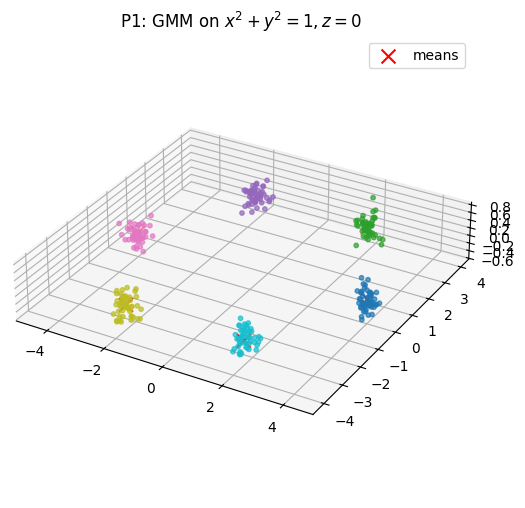

In [80]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# パラメータ
# ----------------------------
K = 6                 # 成分数
N = 300               # 総サンプル数
sigma = 0.2          # 分散スケール

# ----------------------------
# 円周上の6等分点（平均）
# ----------------------------
radius = 4  # 半径を3に変更
theta = np.linspace(0, 2*np.pi, K, endpoint=False)
means = np.stack([
    radius * np.cos(theta),
    radius * np.sin(theta),
    np.zeros(K)
], axis=1)   # shape (6,3)

# ----------------------------
# 共分散（全成分共通）
# ----------------------------
Sigma = sigma**2 * np.eye(3)

# ----------------------------
# GMMからサンプリング
# ----------------------------
points = []
labels = []

for k in range(K):
    Nk = N // K
    samples = np.random.multivariate_normal(
        mean=means[k],
        cov=Sigma,
        size=Nk
    )
    points.append(samples)
    labels.append(np.full(Nk, k))

P_1 = np.vstack(points)
labels = np.concatenate(labels)

# ----------------------------
# 可視化
# ----------------------------
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    P_1[:,0], P_1[:,1], P_1[:,2],
    c=labels, cmap="tab10", s=10, alpha=0.7
)

ax.scatter(
    means[:,0], means[:,1], means[:,2],
    c="red", s=100, marker="x", label="means"
)

ax.set_title("P1: GMM on $x^2+y^2=1, z=0$")
ax.set_box_aspect([1,1,0.2])
ax.legend()
plt.show()


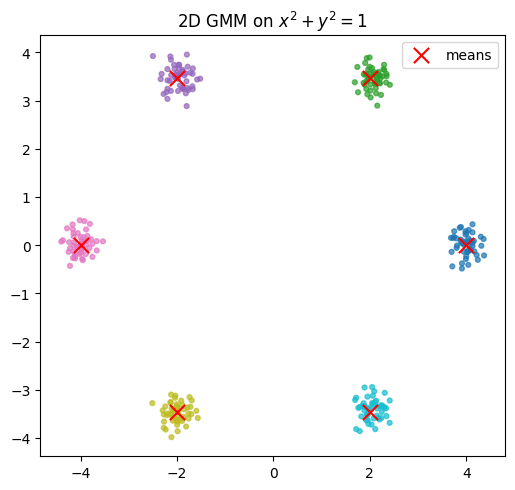

In [81]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# パラメータ
# ----------------------------
K = 6
N = 300
sigma = 0.2

# ----------------------------
# 円周上6等分点（平均）
# ----------------------------
theta = np.linspace(0, 2*np.pi, K, endpoint=False)
means_2d = np.stack([
    radius*np.cos(theta),
    radius*np.sin(theta)
], axis=1)   # (6,2)

# ----------------------------
# 共分散（共通）
# ----------------------------
Sigma_2d = sigma**2 * np.eye(2)

# ----------------------------
# サンプリング
# ----------------------------
points_2d = []
labels_2d = []

for k in range(K):
    Nk = N // K
    samples = np.random.multivariate_normal(
        mean=means_2d[k],
        cov=Sigma_2d,
        size=Nk
    )
    points_2d.append(samples)
    labels_2d.append(np.full(Nk, k))

P1_2d = np.vstack(points_2d)
labels_2d = np.concatenate(labels_2d)

# ----------------------------
# 可視化
# ----------------------------
plt.figure(figsize=(6,6))
plt.scatter(
    P1_2d[:,0], P1_2d[:,1],
    c=labels_2d, cmap="tab10", s=12, alpha=0.7
)
plt.scatter(
    means_2d[:,0], means_2d[:,1],
    c="red", s=120, marker="x", label="means"
)
plt.gca().set_aspect("equal")
plt.title("2D GMM on $x^2 + y^2 = 1$")
plt.legend()
plt.show()


In [82]:
P1_3d = np.hstack([
    P1_2d,
    np.zeros((P1_2d.shape[0], 1))
])
# --- means_2d が既にある前提 ---
means_3d = np.hstack([
    means_2d,
    np.zeros((means_2d.shape[0], 1))
])


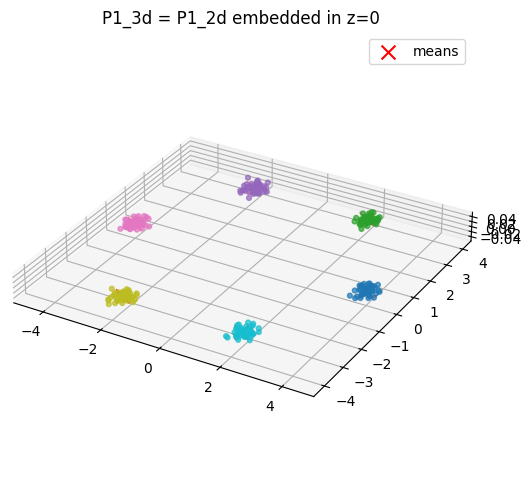

In [83]:
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    P1_3d[:,0], P1_3d[:,1], P1_3d[:,2],
    c=labels_2d, cmap="tab10", s=12, alpha=0.7
)

ax.scatter(
    means_3d[:,0], means_3d[:,1], means_3d[:,2],
    c="red", s=100, marker="x", label="means"
)

ax.set_title("P1_3d = P1_2d embedded in z=0")
ax.set_box_aspect([1,1,0.1])
ax.legend()
plt.show()


In [84]:
n_noise = 10
noise_center = np.array([2.5*radius, 0.0, 10.0])
noise_radius = 0.3

u = np.random.normal(size=(n_noise, 3))
u /= np.linalg.norm(u, axis=1, keepdims=True)
r_rand = noise_radius * np.random.uniform(0, 1, n_noise) ** (1/3)

P3 = noise_center + u * r_rand[:, None]

In [85]:

P2=P_1 + (0,0,10)

P1= P2[:, :2]

P1_3d = np.hstack([
    P1,
    np.zeros((P1_2d.shape[0], 1))
])

P1=2.5*P1_3d



P23 = 2*np.vstack([P2, P3]) + (0,0,5)

In [86]:
def set_equal_3d_axes(ax, points, margin=0.1):
    mins = points.min(axis=0)
    maxs = points.max(axis=0)

    center = 0.5 * (mins + maxs)
    radius = 0.5 * (maxs - mins).max()
    radius *= (1 + margin)

    ax.set_xlim(center[0] - radius, center[0] + radius)
    ax.set_ylim(center[1] - radius, center[1] + radius)
    ax.set_zlim(center[2] - radius, center[2] + radius)

    ax.set_box_aspect([1, 1, 1])


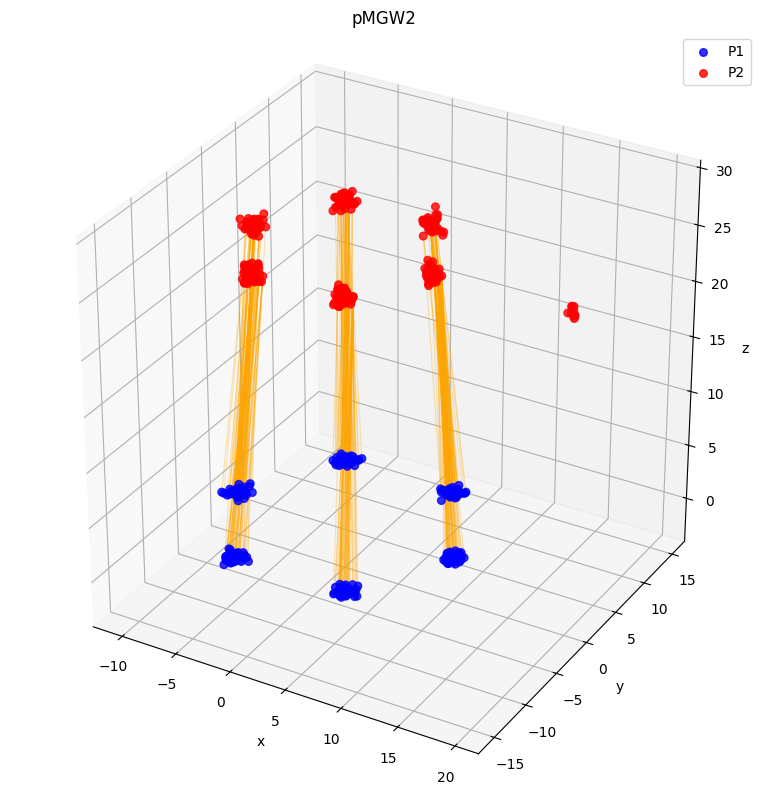

CPU times: user 2.67 s, sys: 11.7 ms, total: 2.69 s
Wall time: 3.03 s


In [87]:
%%time
import numpy as np
import matplotlib.pyplot as plt
idx = pMGW2_coup(
    X=P1, Y=P23,
    Lambda=0.10,
    n_components_X=6,
    n_components_Y=7,
    solver_tol=1e-12,
    points = True
)
# -------------------------
# スケール定義（元の図と一致）
# -------------------------
all_points = np.vstack([P1, P23])

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection="3d")

# -------------------------
# 点群の描画
# -------------------------
ax.scatter(*P1.T, s=30, c="blue", label="P1", alpha=0.8)
ax.scatter(*P23.T, s=30, c="red", label="P2", alpha=0.8)

# -------------------------
# 線分マッチング
# -------------------------
num_lines = min(300, len(P1))   # 描きすぎ防止
sample_idx = np.random.choice(len(P1), num_lines, replace=False)

for i in sample_idx:
    j = idx[i]
    ax.plot(
        [P1[i,0], P23[j,0]],
        [P1[i,1], P23[j,1]],
        [P1[i,2], P23[j,2]],
        c="orange",
        alpha=0.3,
        linewidth=0.8
    )

# -------------------------
# 軸・表示設定
# -------------------------
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("pMGW2")
ax.legend()

set_equal_3d_axes(ax, all_points)

plt.tight_layout()
plt.savefig("pmgw_coupling.eps", format="eps", dpi=500)
plt.show()

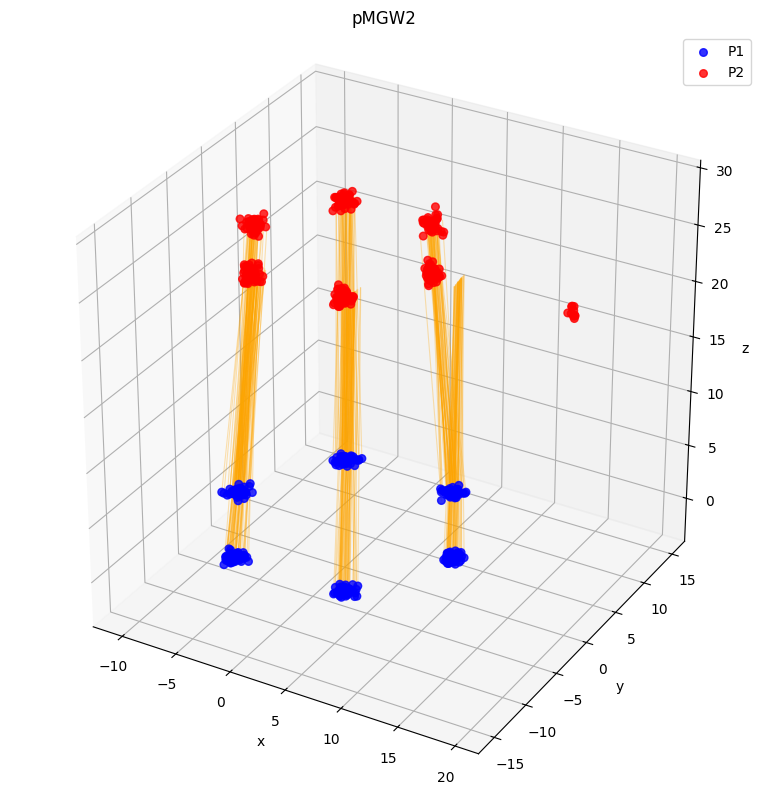

CPU times: user 3.17 s, sys: 8.18 ms, total: 3.18 s
Wall time: 4.33 s


In [88]:
%%time
import numpy as np
import matplotlib.pyplot as plt
idx = pMGW2_coup(
    X=P1, Y=P23,
    Lambda=0.10,
    n_components_X=6,
    n_components_Y=7,
    solver_tol=1e-12,
    points = False # 重心射影の点を返すように変更
)
# -------------------------
# スケール定義（元の図と一致）
# -------------------------
all_points = np.vstack([P1, P23])

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection="3d")

# -------------------------
# 点群の描画
# -------------------------
ax.scatter(*P1.T, s=30, c="blue", label="P1", alpha=0.8)
ax.scatter(*P23.T, s=30, c="red", label="P2", alpha=0.8)

# -------------------------
# 線分マッチング
# -------------------------
num_lines = min(300, len(P1))   # 描きすぎ防止
sample_idx = np.random.choice(len(P1), num_lines, replace=False)

for i in sample_idx:
    mapped_point = idx[i] # idx[i] は直接座標となる
    ax.plot(
        [P1[i,0], mapped_point[0]],
        [P1[i,1], mapped_point[1]],
        [P1[i,2], mapped_point[2]],
        c="orange",
        alpha=0.3,
        linewidth=0.8
    )

# -------------------------
# 軸・表示設定
# -------------------------
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("pMGW2")
ax.legend()

set_equal_3d_axes(ax, all_points)

plt.tight_layout()
plt.savefig("pmgw_bary.eps", format="eps", dpi=500)
plt.show()

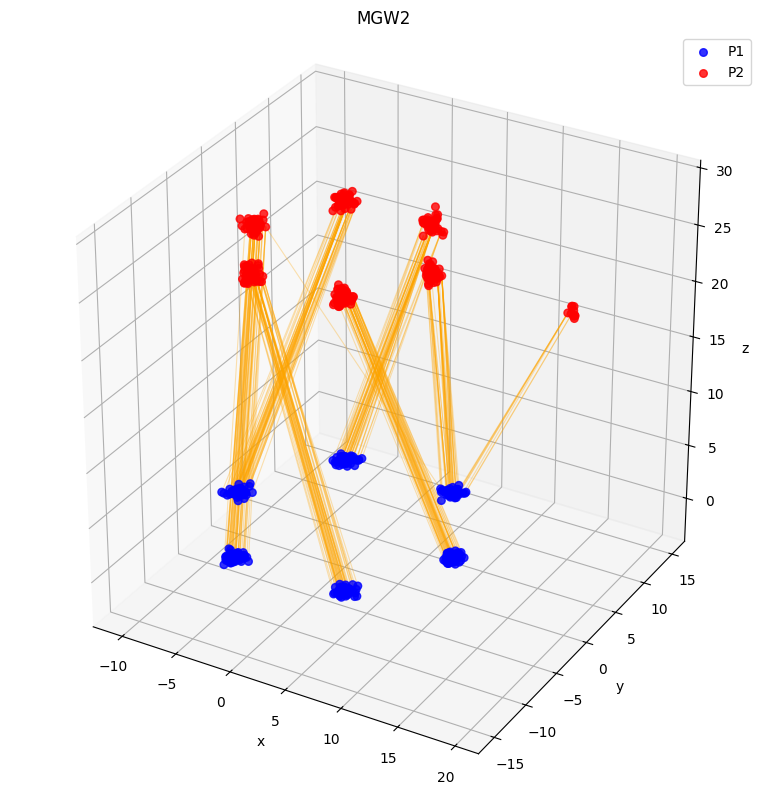

CPU times: user 3.4 s, sys: 15.8 ms, total: 3.42 s
Wall time: 5.62 s


In [89]:
%%time
import numpy as np
import matplotlib.pyplot as plt
idy = MGW2_coup(X=P1,Y= P23,n_components=6,annealing=False,method='T_mean',points=True,return_both=False,verbose=False)
# -------------------------
# スケール定義（元の図と一致）
# -------------------------
all_points = np.vstack([P1, P23])

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection="3d")

# -------------------------
# 点群の描画
# -------------------------
ax.scatter(*P1.T, s=30, c="blue", label="P1", alpha=0.8)
ax.scatter(*P23.T, s=30, c="red", label="P2", alpha=0.8)

# -------------------------
# 線分マッチング
# -------------------------
num_lines = min(300, len(P1))   # 描きすぎ防止
sample_idy = np.random.choice(len(P1), num_lines, replace=False)

for i in sample_idy:
    j = idy[i]
    ax.plot(
        [P1[i,0], P23[j,0]],
        [P1[i,1], P23[j,1]],
        [P1[i,2], P23[j,2]],
        c="orange",
        alpha=0.3,
        linewidth=0.8
    )

# -------------------------
# 軸・表示設定
# -------------------------
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("MGW2")
ax.legend()

set_equal_3d_axes(ax, all_points)

plt.tight_layout()
plt.savefig("mgw_coupling.eps", format="eps", dpi=500)
plt.show()

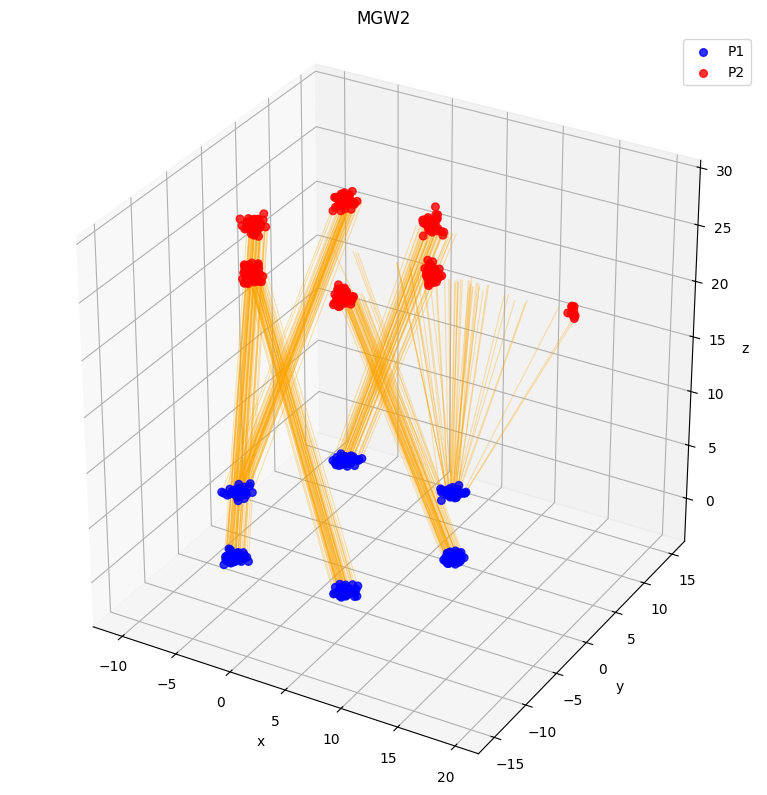

CPU times: user 3.33 s, sys: 17.1 ms, total: 3.35 s
Wall time: 4.43 s


In [90]:
%%time
import numpy as np
import matplotlib.pyplot as plt
bidy = MGW2_coup(X=P1,Y= P23,n_components=6,annealing=False,method='T_mean',points=False,return_both=False,verbose=False)
# -------------------------
# スケール定義（元の図と一致）
# -------------------------
all_points = np.vstack([P1, P23])

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection="3d")

# -------------------------
# 点群の描画
# -------------------------
ax.scatter(*P1.T, s=30, c="blue", label="P1", alpha=0.8)
ax.scatter(*P23.T, s=30, c="red", label="P2", alpha=0.8)

# -------------------------
# 線分マッチング
# -------------------------
num_lines = min(300, len(P1))   # 描きすぎ防止
sample_idy = np.random.choice(len(P1), num_lines, replace=False)

for i in sample_idy:
    mapped_point = bidy[i] # bidy[i] は直接座標となる
    ax.plot(
        [P1[i,0], mapped_point[0]], # P23[j,0] ではなく mapped_point[0] を使用
        [P1[i,1], mapped_point[1]], # P23[j,1] ではなく mapped_point[1] を使用
        [P1[i,2], mapped_point[2]], # P23[j,2] ではなく mapped_point[2] を使用
        c="orange",
        alpha=0.3,
        linewidth=0.8
    )

# -------------------------
# 軸・表示設定
# -------------------------
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("MGW2")
ax.legend()

set_equal_3d_axes(ax, all_points)

plt.tight_layout()
plt.savefig("mgw_bary.eps", format="eps", dpi=500)
plt.show()

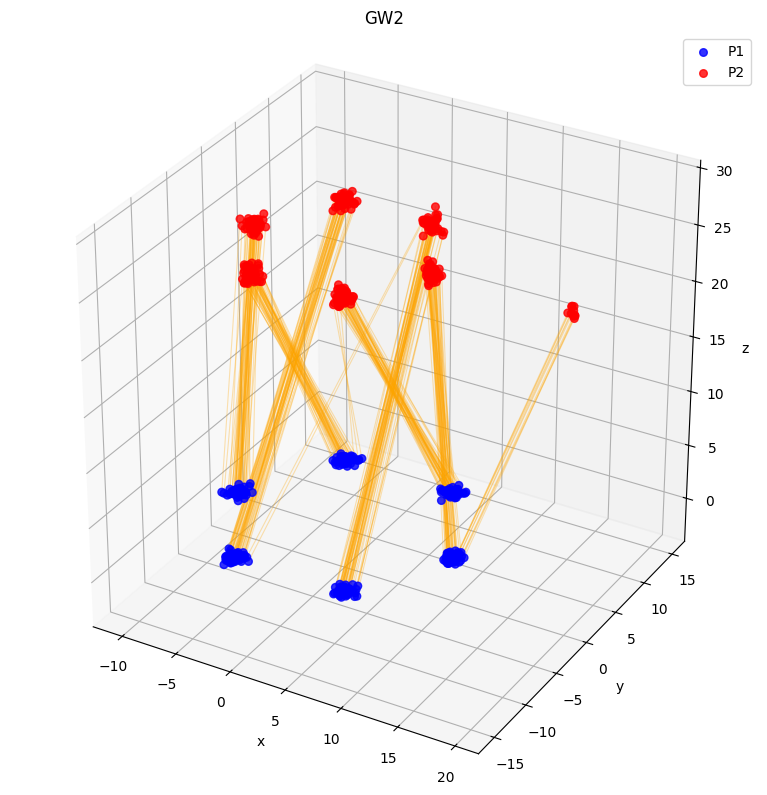

CPU times: user 2.55 s, sys: 18.2 ms, total: 2.57 s
Wall time: 3.22 s


In [91]:
%%time
import ot
import numpy as np
import matplotlib.pyplot as plt

# 1. 距離行列の計算
C1 = ot.dist(P1, P1)
C23 = ot.dist(P23, P23)

M1 = np.max(C1)
M2 = np.max(C23)
M = np.max([M1,M2])
C1 = C1/M
C23 = C23/M

# 2. 重みの設定（一様分布）
p = ot.unif(len(P1))
q = ot.unif(len(P23))

# 3. Gromov-Wasserstein 輸送行列の計算
# P1 と P23 の相対的な位置関係のみに基づいてマッチング
G = ot.gromov_wasserstein(C1, C23, p, q, 'square_loss', epsilon=5e-3)

# --- 可視化 ---
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

# 全点群を結合して軸の範囲を決定するために使用
all_points = np.vstack([P1, P23])

# 点群の描画
ax.scatter(P1[:, 0], P1[:, 1], P1[:, 2], color='blue', label='P1', s=30, alpha=0.8)
ax.scatter(P23[:, 0], P23[:, 1], P23[:, 2], color='red', label='P2', s=30, alpha=0.8)

# マッチングの線を描画 (輸送確率が高い上位のペアのみ)
# 全て描くと重くなるため、各点から最も確率が高い対応先への線を描画
for i in range(len(P1)):
    j = np.argmax(G[i, :])
    if G[i, j] > 1e-5: # 有意な結合のみ
        ax.plot(
            [P1[i, 0], P23[j, 0]],
            [P1[i, 1], P23[j, 1]],
            [P1[i, 2], P23[j, 2]],
            color='orange', alpha=0.3, linewidth=0.8
        )

# 自作関数でアスペクト比を等しく設定
set_equal_3d_axes(ax, all_points)



ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("GW2")
ax.legend()

set_equal_3d_axes(ax, all_points)

plt.tight_layout()
plt.savefig("gw_coupling.eps", format="eps", dpi=500)
plt.show()


It.  |Err         |Loss        
-------------------------------
    0|4.588262e-02|2.065757e-02


/content/PGW_Metric/lib/gromov.py:790: UserWarning: This function will be deprecated in a near future, please use ot.gromov.gwloss` instead.
  print("{:5d}|{:8e}|{:8e}".format(cpt, err, gwloss_partial(C1, C2, G0)))
/usr/local/lib/python3.12/dist-packages/ot/partial/partial_solvers.py:887: UserWarning: This function will be deprecated in a near future, please use ot.gromov.gwggrad` instead.
  g = gwgrad_partial(C1, C2, T) * 0.5


Calculation time: 0.426331 sec
Total transported mass: 0.9677


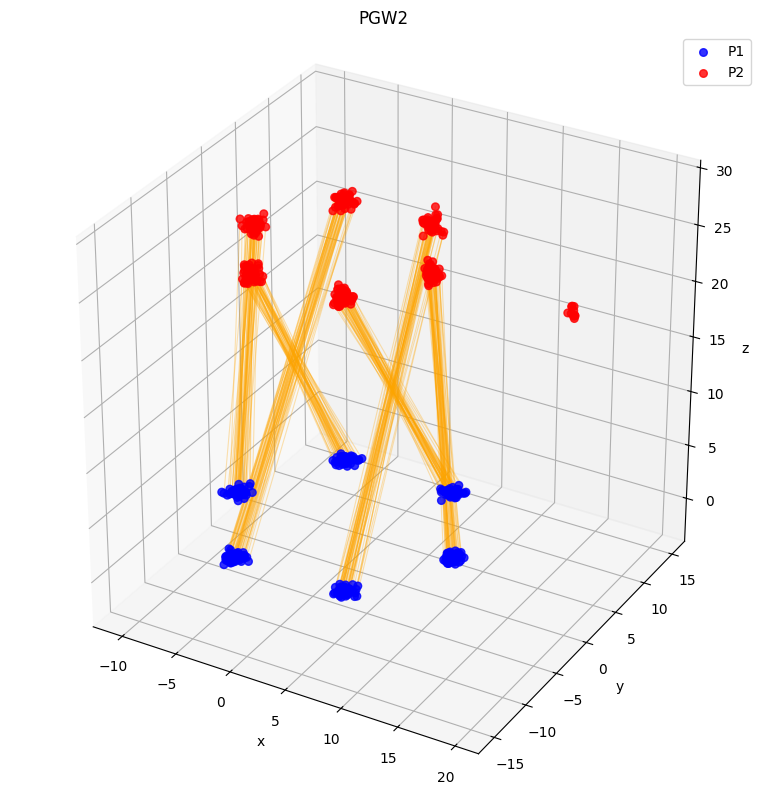

In [92]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import time

# --- 前提: 記憶したコードから必要な関数をインポート/定義済みとする ---
# ここでは partial_gromov_ver2 (あるいは ver1) を使う想定です
# Lambda は部分輸送のペナルティ項として機能します

## データの準備 (例として P1 と P23 を定義)
# P1: ソース点群, P23: ターゲット点群 (P23の方が点数が多い、または一部のみ対応する想定)
n1, n2 = len(P1), len(P23)
C1 = ot.dist(P1, P1)
C23 = ot.dist(P23, P23)
M1 = np.max(C1)
M2 = np.max(C23)
M = np.max([M1,M2])
C1 = C1/M
C23 = C23/M

# 重みの設定
p = np.ones(n1) / n1
q = np.ones(n2) / n2

# 輸送したい質量の割合 (例: 全体の 80% だけをマッチングさせる)
# ※ご提示のコードの引数に合わせて調整してください
# m = 0.8 * min(np.sum(p), np.sum(q))

start_time = time.time()

## 3. Partial Gromov-Wasserstein の計算
# 記憶したコードの partial_gromov_ver2 を呼び出し
# Lambda: 輸送されない点へのペナルティ。小さいほど「無理に繋がない」ようになります。
G_partial =  gromov.partial_gromov_ver1(
    C1, C23, p, q,
    Lambda=0.04,       # 距離のスケールに合わせて調整
    numItermax_gw=100,
    verbose=True
)

print(f"Calculation time: {time.time() - start_time:.6f} sec")
print(f"Total transported mass: {np.sum(G_partial):.4f}")

# --- 可視化 ---
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

all_points = np.vstack([P1, P23])

# 点群の描画
ax.scatter(P1[:, 0], P1[:, 1], P1[:, 2], color='blue', label='P1', s=30, alpha=0.8)
ax.scatter(P23[:, 0], P23[:, 1], P23[:, 2], color='red', label='P2', s=30, alpha=0.8)

# マッチングの線を描画 (Partial GW なので、結合が薄い点は無視される)
# 各ソース点 i について、最も結合が強いターゲット点 j を探す
for i in range(len(P1)):
    j = np.argmax(G_partial[i, :])
    # 閾値判定: 輸送が非常に低い（マッチングから外された）点は描画しない
    if G_partial[i, j] > (0.1 / n1):
        ax.plot(
            [P1[i, 0], P23[j, 0]],
            [P1[i, 1], P23[j, 1]],
            [P1[i, 2], P23[j, 2]],
            color='orange', alpha=0.3, linewidth=0.8
        )

# アスペクト比の設定
set_equal_3d_axes(ax, all_points)



ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("PGW2")
ax.legend()

set_equal_3d_axes(ax, all_points)

plt.tight_layout()
plt.savefig("pgw_coupling.eps", format="eps", dpi=500)
plt.show()